# 🧠 NLP Foundations Workshop: Vector Space Proximity

### 🔹 Introduction to Vector Space Proximity

A large majority of the data on the Internet is **unstructured**, for example: social media posts, emails, images, videos and audio files.

If we want to **persist** all these media in a database, we may add **metadata** about them, such as file type or creation date timestamp, or we could  **tag** each file, or parts of it, so they are easy to search for. This is because it would be very difficult to identify them based on their low-level (byte) representations.

But, what if we want to make the process fully automated (i.e., remove the need to manually add features, like tags, to each media item)? We need another way to represent the semantics of digital media.

That is the reason why in **Information Retrieval (IR)** and **Natural Language Processing (NLP)**, we often represent documents and queries as **vectors** in a **high-dimensional space**, where:

* Each **dimension** corresponds to a **unique term** in the vocabulary.
* A **document** is represented by a **point** or a **vector** in the space.
* A **vector** is a list of weights (e.g., term frequencies, TF-IDF values) that describe the presence or importance of terms in a document or query.

---

#### 📘 Example 1: "Rich" and "Poor" Axes

![Vector Space Example: "Rich" and "Poor" Axes"](./images/Fig1_CartesianVectorSpace.png)

Suppose our vocabulary only has two terms:

* `"rich"`
* `"poor"`

These two terms define a **2D Cartesian space**:

* The **x-axis** corresponds to the term **"rich"**.
* The **y-axis** corresponds to the term **"poor"**.

Each document is represented as a vector in this space:

* A document with many occurrences of “poor” and none of “rich” lies near the **y-axis**.
* A document that mentions both “rich” and “poor” lies in the **first quadrant**.
* A document with only “rich” is aligned along the **x-axis**.

The **query vector** $q = \{\text{"rich"}, \text{"poor"}\}$ points in the direction of interest for the search engine.

### 🔹 Euclidean Distance and Its Limitations

One might assume we can measure similarity using **Euclidean distance**:

$$
\text{Euclidean}( \vec{q}, \vec{d} ) = \sqrt{ \sum_{i=1}^{n} (q_i - d_i)^2 }
$$

However, this has problems in practice:

* If document $d_2$ contains more occurrences of both “rich” and “poor” than the query, its vector will have a **longer length**.
* As seen in the diagram, even though $d_2$ has strong content overlap with the query $q$, it may still be **further away** in Euclidean terms than unrelated documents like $d_3$.
* This happens because **magnitude dominates**, not direction.

### 🔹 Angle as Similarity → Cosine Similarity

To solve this, we focus on **vector direction**, not length. We measure **angle** between the document and query vectors using **Cosine Similarity**:

$$
\cos(\vec{q}, \vec{d}) = \frac{ \vec{q} \cdot \vec{d} }{ \|\vec{q}\| \cdot \|\vec{d}\| }
= \frac{ \sum_{i=1}^{n} q_i \cdot d_i }{ \sqrt{ \sum_{i=1}^{n} q_i^2 } \cdot \sqrt{ \sum_{i=1}^{n} d_i^2 } }
$$

* This gives us a similarity score from **0 (orthogonal)** to **1 (identical direction)**.
* Longer documents that are semantically aligned still get **high similarity**.

### 🔹 Why Cosine Similarity Works Better

* **Angle** captures **semantic alignment**.
* It is **not affected** by document length or repetition.
* Example: duplicating document $d$ to make $d'$ will increase Euclidean distance — but **cosine similarity remains 1**.

Cosine similarity is at the core of:

* **Search ranking**
* **Embedding-based retrieval**
* **LLM scoring and attention mechanisms**

Sample code:

In [18]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the documents and the query
documents = [
    "Ranks of starving poets swell",       # d1
    "Rich poor gap grows",                 # d2
    "Record baseball salaries in 2010"     # d3
]

query = ["rich poor"]                     # q

# Create a CountVectorizer to convert text to term frequency vectors
vectorizer = CountVectorizer()
doc_vectors = vectorizer.fit_transform(documents + query).toarray()

# Separate vectors
doc_matrix = doc_vectors[:3]  # d1, d2, d3
query_vector = doc_vectors[3].reshape(1, -1)  # q

# Compute cosine similarity
cosine_similarities = cosine_similarity(query_vector, doc_matrix).flatten()

# Create a DataFrame to show results
df = pd.DataFrame({
    'Document': ['Doc1', 'Doc2', 'Doc3'],
    'Cosine Similarity with Query': cosine_similarities
})

# Sort for clarity
print("Query: ", query)
df.sort_values(by='Cosine Similarity with Query', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

# Display the result
df


Query:  ['rich poor']


,Document,Cosine Similarity with Query
0,Doc2,0.707107
1,Doc1,0.000000
2,Doc3,0.000000


### 📘 Example 2: Word Vectors in a Small Corpus

Let's start with a small corpus of just six words, each represented by a vector in 3D space:

```plaintext
CAT     → [ 0.2, -0.4,  0.7]
DOG     → [ 0.6,  0.1,  0.5]
APPLE   → [ 0.8, -0.2, -0.3]
ORANGE  → [ 0.7, -0.1, -0.6]
HAPPY   → [-0.5,  0.9,  0.2]
SAD     → [ 0.4, -0.7, -0.5]
```

Each term is represented by a **vector in 3D space**.

### 🔍 Observations

- Words with **similar meanings** tend to have **similar vector representations**.
  - For example, **APPLE** and **ORANGE** are close in vector space, reflecting their semantic similarity.

- Words with **opposite meanings** tend to have **vectors pointing in opposite directions**.
  - For instance, **HAPPY** and **SAD** have contrasting vectors, indicating their opposing emotional tones.

![3D Visualizationof Word Vectors](./images/Fig2_3DVisualizationWordVectors.png)



### 🔹 Embeddings and Frequency-Based Representations

Vector representations are also called **embeddings**.

One simple family of embeddings is **frequency-based embeddings**. These represent documents numerically using statistics derived from the corpus. A classical example is **TF-IDF**.

TF-IDF highlights words that are frequent within a specific document but rare across the entire corpus. For example, in a document about music, it would emphasize words such as **rap**, **disco**, **pop**, and **rock**, while common pronouns and function words receive low weights.

This workshop stays focused on **Vector Space Proximity** and the use of these vector representations for **matching**, **retrieval**, and **evaluation**.


### 🔹 Transition to Evaluation

Once we represent documents and queries as vectors and compute proximity scores, the next question is:

> **How do we know whether the retrieval system is doing a good job?**

To answer that, we need **evaluation**.


## 🔹 Evaluation of an Information Retrieval System

In Information Retrieval, an **information need** is translated into a **query**.

For example:

- **Information need**: *I want information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.*
- **Possible query**: `green tea coffee heart attack effective`

This distinction matters because **relevance is assessed relative to the information need, not the query string itself**.

A document is **relevant** if it addresses the user's real need. A document is **not automatically relevant** just because it contains the words `green`, `tea`, `coffee`, or `heart attack`.

### ✅ Key idea

When evaluating an IR system, we ask:

- Did the system retrieve documents that actually satisfy the information need?
- Not merely: did the system retrieve documents that share words with the query?


In [19]:
import pandas as pd

# Benchmark collection for one information need
documents_eval = {
    "Doc1": "A medical review compares green tea and coffee for cardiovascular health and heart attack risk.",
    "Doc2": "Green tea contains antioxidants that may support heart health.",
    "Doc3": "Coffee prices increased this year because of climate conditions affecting crops.",
    "Doc4": "Heart attack warning signs and emergency response guidelines.",
    "Doc5": "A study discusses whether green tea is more effective than coffee in lowering heart attack risk.",
    "Doc6": "The history of tea drinking in East Asia."
}

information_need = (
    "Find information on whether drinking green tea is more effective than coffee "
    "at reducing the risk of heart attacks."
)

query_eval = "green tea coffee heart attack effective"

benchmark_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Text": list(documents_eval.values())
})

print("Information Need:")
print(information_need)
print("\nQuery:")
print(query_eval)
print("\nBenchmark Collection:")
benchmark_df


Information Need:
Find information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.

Query:
green tea coffee heart attack effective

Benchmark Collection:


,Document,Text
0,Doc1,A medical review compares green tea and coffee for cardiovascular health and heart attack risk.
1,Doc2,Green tea contains antioxidants that may support heart health.
2,Doc3,Coffee prices increased this year because of climate conditions affecting crops.
3,Doc4,Heart attack warning signs and emergency response guidelines.
4,Doc5,A study discusses whether green tea is more effective than coffee in lowering heart attack risk.
5,Doc6,The history of tea drinking in East Asia.


## 🔹 Evaluating Unranked Results

For **unranked retrieval**, the system returns a **set** of documents, not an ordered list.

To evaluate such a result set, we usually need:

- A **benchmark document collection**
- A **benchmark set of queries**
- A **relevance assessment** for each query-document pair, often created manually by experts

This turns the problem into a **classification-style setup**:

- **Relevant**
- **Nonrelevant**

### Important note

Although **accuracy** is common in machine learning classification, it is **not the main metric in IR**.

Why?

Because in IR, the number of nonrelevant documents is often huge. A system can get high accuracy simply by labeling most documents as nonrelevant, while still failing to retrieve the relevant ones the user actually needs.

So for unranked IR, we focus on measures such as:

- **Precision**
- **Recall**
- **F1-score**

Where:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Manual relevance judgments relative to the INFORMATION NEED, not just the query words.
# 1 = relevant, 0 = nonrelevant
relevance_judgments = {
    "Doc1": 1,  # directly compares green tea and coffee for heart attack risk
    "Doc2": 0,  # about green tea and heart health, but does not answer the comparison
    "Doc3": 0,  # contains coffee topic but unrelated to health effectiveness
    "Doc4": 0,  # about heart attacks, but not about green tea vs coffee
    "Doc5": 1,  # directly addresses the information need
    "Doc6": 0   # about tea history, not the medical comparison
}

# A simple UNRANKED retrieval rule:
# retrieve a document if it contains at least one query term
vectorizer_eval = CountVectorizer(binary=True)
X_eval = vectorizer_eval.fit_transform(list(documents_eval.values()) + [query_eval]).toarray()

doc_term_matrix = X_eval[:-1]
query_vector_eval = X_eval[-1]

# Unranked retrieval: retrieve if there is any overlap with the query
retrieved_flags = (doc_term_matrix @ query_vector_eval > 0).astype(int)

results_eval = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Retrieved": retrieved_flags,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()],
    "Text": list(documents_eval.values())
})

results_eval


,Document,Retrieved,Relevant,Text
0,Doc1,1,1,A medical review compares green tea and coffee for cardiovascular health and heart attack risk.
1,Doc2,1,0,Green tea contains antioxidants that may support heart health.
2,Doc3,1,0,Coffee prices increased this year because of climate conditions affecting crops.
3,Doc4,1,0,Heart attack warning signs and emergency response guidelines.
4,Doc5,1,1,A study discusses whether green tea is more effective than coffee in lowering heart attack risk.
5,Doc6,1,0,The history of tea drinking in East Asia.


## 🔹 Computing Precision and Recall for the Unranked Result Set

Now we compare the system's retrieved set against the benchmark relevance judgments.

We define:

- **TP (True Positives)**: retrieved and relevant
- **FP (False Positives)**: retrieved but nonrelevant
- **FN (False Negatives)**: not retrieved but relevant
- **TN (True Negatives)**: not retrieved and nonrelevant

In IR, the most informative questions are:

- Of the documents we retrieved, how many were actually useful? → **Precision**
- Of all relevant documents that exist, how many did we find? → **Recall**

This tells us whether the retrieval strategy is too broad, too narrow, or balanced.


In [21]:
# Compute confusion-matrix style counts
tp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 1)).sum())
fp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 0)).sum())
fn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 1)).sum())
tn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)

summary_df = pd.DataFrame({
    "Metric": ["TP", "FP", "FN", "TN", "Precision", "Recall", "F1", "Accuracy"],
    "Value": [tp, fp, fn, tn, round(precision, 3), round(recall, 3), round(f1, 3), round(accuracy, 3)]
})

summary_df


,Metric,Value
0,TP,2.000
1,FP,4.000
2,FN,0.000
3,TN,0.000
4,Precision,0.333
5,Recall,1.000
6,F1,0.500
7,Accuracy,0.333


## 🔹 Interpreting the Results

Notice how **accuracy** can look acceptable even when the retrieval behavior is not ideal.

For IR, **precision** and **recall** are more meaningful because they focus on the documents that matter to the user's information need.

### Reflection questions for students

1. Which retrieved documents were **false positives**, and why?
2. Which relevant documents might be missed by a simple lexical query-matching rule?
3. How might **TF-IDF weighting** and **cosine similarity** improve retrieval compared with a simple overlap rule?
4. Why is relevance judged relative to the **information need** rather than the exact query wording?

This sets up the next step in IR evaluation: moving from **unranked result sets** to **ranked retrieval**, where order also matters.


## 🔹 Confusion Matrix for Unranked Retrieval

For **unranked IR evaluation**, we can summarize the result set using a **confusion matrix**.

We compare two things for each document:

- **Did the system retrieve it?**
- **Is it actually relevant to the information need?**

This gives four cases:

- **TP (True Positive)**: retrieved and relevant
- **FP (False Positive)**: retrieved but nonrelevant
- **FN (False Negative)**: not retrieved but relevant
- **TN (True Negative)**: not retrieved and nonrelevant

In IR notation:

- \( P \): total number of relevant documents
- \( N \): total number of nonrelevant documents
- \( \hat{P} \): number of retrieved documents
- \( \hat{N} \): number of not retrieved documents

The confusion matrix helps us connect retrieval behavior to evaluation metrics such as **precision**, **recall**, and **F-measure**.


In [22]:
import pandas as pd

# Build a simple confusion-matrix-style table from the counts already computed
confusion_display = pd.DataFrame(
    [
        [tp, fn, tp + fn],
        [fp, tn, fp + tn],
        [tp + fp, fn + tn, tp + fp + fn + tn]
    ],
    index=["Relevant", "Nonrelevant", "Total"],
    columns=["Retrieved", "Not retrieved", "Total"]
)

print("Confusion Matrix for the Unranked Result Set:")
confusion_display


Confusion Matrix for the Unranked Result Set:


,Retrieved,Not retrieved,Total
Relevant,2,0,2
Nonrelevant,4,0,4
Total,6,0,6


## 🔹 Precision–Recall Discussion

A key idea in Information Retrieval is the **tradeoff between precision and recall**.

### Precision

Precision asks:

> Of the documents the system retrieved, how many were actually relevant?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

High precision means the system returns **few false positives**.

---

### Recall

Recall asks:

> Of all relevant documents in the collection, how many did the system find?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

High recall means the system returns **few false negatives**.

---

### Why the tradeoff matters

- You can get **high recall** by retrieving many documents, even **all documents**
- But then precision usually drops, because many retrieved documents are nonrelevant
- In a good IR system, as the number of retrieved documents increases, **recall tends to go up** while **precision often goes down**

---

### F-Measure

To balance precision and recall, we often use the **F-measure** (harmonic mean):

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

The harmonic mean is used because it penalizes systems that do well on one metric but poorly on the other.

### Key interpretation

- **High precision, low recall**: the system is conservative and misses relevant documents
- **Low precision, high recall**: the system retrieves many relevant documents, but also too many irrelevant ones
- **Balanced F1**: the system has a good compromise between the two


Ranked prefixes and their precision/recall values:


,Document,OverlapScore,Relevant
0,Doc5,6,1
1,Doc1,5,1
2,Doc2,3,0
3,Doc4,2,0
4,Doc3,1,0
5,Doc6,1,0


,k,Precision@k,Recall@k
0,1,1.000,0.5
1,2,1.000,1.0
2,3,0.667,1.0
3,4,0.500,1.0
4,5,0.400,1.0
5,6,0.333,1.0


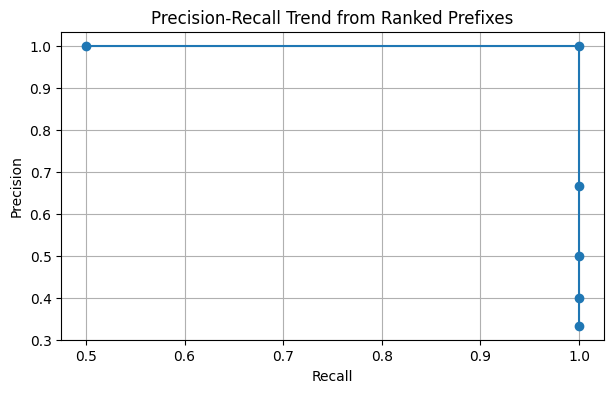

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Precision-recall style thought experiment:
# rank documents by simple query overlap score, then evaluate prefixes of the ranked list

overlap_scores = (doc_term_matrix @ query_vector_eval).astype(int)

ranked_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "OverlapScore": overlap_scores,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()]
}).sort_values(by=["OverlapScore", "Document"], ascending=[False, True]).reset_index(drop=True)

precision_values = []
recall_values = []
k_values = []

num_relevant = ranked_df["Relevant"].sum()
tp_running = 0
fp_running = 0

for k in range(1, len(ranked_df) + 1):
    current_rel = ranked_df.loc[k - 1, "Relevant"]
    if current_rel == 1:
        tp_running += 1
    else:
        fp_running += 1

    precision_k = tp_running / (tp_running + fp_running)
    recall_k = tp_running / num_relevant if num_relevant > 0 else 0

    k_values.append(k)
    precision_values.append(precision_k)
    recall_values.append(recall_k)

pr_table = pd.DataFrame({
    "k": k_values,
    "Precision@k": np.round(precision_values, 3),
    "Recall@k": np.round(recall_values, 3)
})

print("Ranked prefixes and their precision/recall values:")
display(ranked_df)
display(pr_table)

plt.figure(figsize=(7, 4))
plt.plot(recall_values, precision_values, marker="o")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trend from Ranked Prefixes")
plt.grid(True)
plt.show()


## 🔹 What Students Should Notice

From the confusion matrix and the precision–recall discussion, students should observe that:

1. **Evaluation is tied to the information need**, not just query-term overlap.
2. A system can retrieve many documents and improve **recall**, but this may reduce **precision**.
3. The confusion matrix gives a compact way to understand retrieval outcomes.
4. Precision, recall, and F1 are more informative for IR than plain accuracy.
5. This also prepares us for **ranked retrieval evaluation**, where the order of results matters.

This completes the bridge from **vector representations and proximity** to **practical IR evaluation**.


## 🔹 Interpolated Precision

A retrieval system can return **any number of results**, so the raw precision values observed along a ranking can fluctuate up and down.

To make the precision–recall curve easier to interpret, we use **interpolated precision**.

At a recall level \( r \), the interpolated precision is defined as:

$$
p_{\mathrm{interp}}(r) = \max_{r' \ge r} p(r')
$$

This means:

- look at the current recall level \( r \)
- look to the **right** on the precision–recall curve, at all recall levels \( r' \ge r \)
- take the **highest precision** found there

### Why do this?

It smooths the curve and answers the question:

> "At this recall level or beyond, what is the best precision the system achieves?"

This produces a non-increasing interpolated precision curve, which is often easier to compare across systems.


Raw vs. Interpolated Precision:


,Recall,Raw Precision,Interpolated Precision
0,0.5,1.000,1.000
1,1.0,1.000,1.000
2,1.0,0.667,0.667
3,1.0,0.500,0.500
4,1.0,0.400,0.400
5,1.0,0.333,0.333


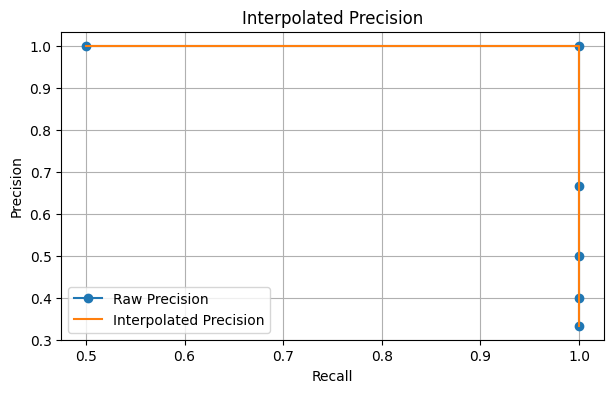

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the recall_values and precision_values computed earlier from ranked prefixes
interp_precision = np.maximum.accumulate(precision_values[::-1])[::-1]

interp_df = pd.DataFrame({
    "Recall": np.round(recall_values, 3),
    "Raw Precision": np.round(precision_values, 3),
    "Interpolated Precision": np.round(interp_precision, 3)
})

print("Raw vs. Interpolated Precision:")
display(interp_df)

plt.figure(figsize=(7, 4))
plt.plot(recall_values, precision_values, marker="o", label="Raw Precision")
plt.step(recall_values, interp_precision, where="post", label="Interpolated Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Interpolated Precision")
plt.grid(True)
plt.legend()
plt.show()


## 🔹 Precision@K and Recall@K

In ranked retrieval, we often care most about the **top of the ranking**.

So instead of evaluating the whole ranked list, we set a threshold \( K \) and only look at the top \( K \) documents.

### Precision@K

Precision@K measures the proportion of relevant documents among the top \( K \) results:

$$
P@K = \frac{\# \text{ relevant documents in top } K}{K}
$$

### Recall@K

Recall@K measures how many of all relevant documents have been found in the top \( K \) results:

$$
R@K = \frac{\# \text{ relevant documents in top } K}{\# \text{ total relevant documents in the collection}}
$$

### Key idea

- **Precision@K** ignores all documents ranked lower than \( K \)
- This is useful when users usually look at only the first few results
- Recall@K complements it by showing how much of the relevant material has already been found


In [25]:
# Example using the ranked list already created earlier
p_at_k_rows = []
total_relevant = ranked_df["Relevant"].sum()
relevant_so_far = 0

for k in range(1, len(ranked_df) + 1):
    if ranked_df.loc[k - 1, "Relevant"] == 1:
        relevant_so_far += 1
    p_at_k = relevant_so_far / k
    r_at_k = relevant_so_far / total_relevant if total_relevant > 0 else 0
    p_at_k_rows.append([k, ranked_df.loc[k - 1, "Document"], ranked_df.loc[k - 1, "Relevant"], round(p_at_k, 3), round(r_at_k, 3)])

p_at_k_df = pd.DataFrame(
    p_at_k_rows,
    columns=["K", "Document at Rank K", "Relevant?", "Precision@K", "Recall@K"]
)

print("Precision@K and Recall@K by rank position:")
p_at_k_df


Precision@K and Recall@K by rank position:


,K,Document at Rank K,Relevant?,Precision@K,Recall@K
0,1,Doc5,1,1.000,0.5
1,2,Doc1,1,1.000,1.0
2,3,Doc2,0,0.667,1.0
3,4,Doc4,0,0.500,1.0
4,5,Doc3,0,0.400,1.0
5,6,Doc6,0,0.333,1.0


## 🔹 Average Precision (AP)

**Average Precision (AP)** summarizes the ranking quality for a **single query**.

The idea is:

1. Find every rank position where a **relevant** document appears
2. Compute **Precision@K** at each of those positions
3. Average those precision values

If the relevant documents appear early in the ranking, AP will be higher.

A common formula is:

$$
AP = \frac{1}{R} \sum_{k=1}^{n} P@k \cdot \mathrm{rel}(k)
$$

Where:

- \( R \) is the number of relevant documents for the query
- \( P@k \) is precision at rank \( k \)
- \( \mathrm{rel}(k) = 1 \) if the document at rank \( k \) is relevant, otherwise \( 0 \)

### Interpretation

AP rewards systems that place relevant documents **near the top** of the ranking, not just somewhere in the list.


In [26]:
# Compute Average Precision (AP) for the current ranked list
relevance_list = ranked_df["Relevant"].tolist()

precision_at_relevant = []
relevant_seen = 0

for k, rel in enumerate(relevance_list, start=1):
    if rel == 1:
        relevant_seen += 1
        precision_k = relevant_seen / k
        precision_at_relevant.append(precision_k)

average_precision = sum(precision_at_relevant) / total_relevant if total_relevant > 0 else 0

ap_details_df = pd.DataFrame({
    "Rank": list(range(1, len(relevance_list) + 1)),
    "Document": ranked_df["Document"],
    "Relevant": relevance_list,
    "Precision@K": [round((sum(relevance_list[:k]) / k), 3) for k in range(1, len(relevance_list) + 1)]
})

print("Average Precision (AP) details:")
display(ap_details_df)
print(f"\nAverage Precision (AP): {average_precision:.3f}")


Average Precision (AP) details:


,Rank,Document,Relevant,Precision@K
0,1,Doc5,1,1.000
1,2,Doc1,1,1.000
2,3,Doc2,0,0.667
3,4,Doc4,0,0.500
4,5,Doc3,0,0.400
5,6,Doc6,0,0.333



Average Precision (AP): 1.000


## 🔹 Mean Reciprocal Rank (MRR)

**Mean Reciprocal Rank (MRR)** is useful when the user mainly wants to find **one good relevant document quickly**.

For a query \( q_j \), let \( R_j \) be the rank of the **first relevant document**.

The reciprocal rank for that query is:

$$
RR_j = \frac{1}{R_j}
$$

Over multiple queries, Mean Reciprocal Rank is:

$$
MRR = \frac{1}{|Q|} \sum_{j=1}^{|Q|} \frac{1}{R_j}
$$

Where:

- \( |Q| \) is the number of queries
- \( R_j \) is the rank of the first relevant result for query \( j \)

### Interpretation

- If the first relevant result is ranked **1st**, reciprocal rank = \( 1.0 \)
- If the first relevant result is ranked **2nd**, reciprocal rank = \( 0.5 \)
- If it is ranked **5th**, reciprocal rank = \( 0.2 \)

MRR is especially appropriate when the user's goal is satisfied by seeing just **one relevant answer near the top**.


In [27]:
# Demonstrate Reciprocal Rank and Mean Reciprocal Rank (MRR) on a few example rankings
example_rankings = {
    "Query1": [1, 0, 0, 0, 0],   # first relevant at rank 1
    "Query2": [0, 1, 0, 1, 0],   # first relevant at rank 2
    "Query3": [0, 0, 0, 1, 0],   # first relevant at rank 4
    "Query4": [0, 0, 0, 0, 0]    # no relevant result found
}

mrr_rows = []
rr_values = []

for query_name, rels in example_rankings.items():
    first_relevant_rank = None
    for rank, rel in enumerate(rels, start=1):
        if rel == 1:
            first_relevant_rank = rank
            break

    rr = 1 / first_relevant_rank if first_relevant_rank is not None else 0
    rr_values.append(rr)
    mrr_rows.append([query_name, rels, first_relevant_rank, round(rr, 3)])

mrr_df = pd.DataFrame(mrr_rows, columns=["Query", "Ranking Relevance Pattern", "First Relevant Rank", "Reciprocal Rank"])
mrr_value = sum(rr_values) / len(rr_values) if rr_values else 0

print("Mean Reciprocal Rank (MRR) example:")
display(mrr_df)
print(f"\nMRR across the example queries: {mrr_value:.3f}")


Mean Reciprocal Rank (MRR) example:


,Query,Ranking Relevance Pattern,First Relevant Rank,Reciprocal Rank
0,Query1,"[1, 0, 0, 0, 0]",1.0,1.00
1,Query2,"[0, 1, 0, 1, 0]",2.0,0.50
2,Query3,"[0, 0, 0, 1, 0]",4.0,0.25
3,Query4,"[0, 0, 0, 0, 0]",NaN,0.00



MRR across the example queries: 0.438


## 🔹 What These Ranked Metrics Add

These ranked evaluation measures help students move beyond simple unranked retrieval:

- **Interpolated Precision** smooths the precision–recall curve
- **Precision@K** focuses on the top of the ranking
- **Average Precision (AP)** rewards rankings that place relevant documents early
- **Mean Reciprocal Rank (MRR)** focuses on how quickly the first useful result appears

Together, these measures connect naturally to **vector space retrieval**, because once documents are ranked by proximity or similarity, we need ways to evaluate **how good that ranking is**.


## 🔹 Creating Test Collections for IR Evaluation

When experts create **test collections** for Information Retrieval, they build the benchmark needed to evaluate a retrieval system.

A typical test collection contains:

- a **document collection**
- a **set of queries or information needs**
- a set of **relevance judgments** indicating whether each document is relevant or nonrelevant for each query

### Why agreement matters

In practice, human judges do **not** agree 100% of the time.

Two experts may disagree about whether a document is relevant, especially when relevance is subjective, partial, or context-dependent.

Because of this, IR evaluation often measures **inter-judge agreement**.

A common measure is **Cohen's Kappa**, which adjusts the observed agreement by subtracting the agreement that could have happened **by chance**.

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Where:

- \( P(A) \) is the **observed agreement**
- \( P(E) \) is the **expected agreement by chance**

### Interpretation

- \( \kappa > 0.8 \): strong agreement
- \( 0.67 < \kappa \le 0.8 \): tentative but useful agreement
- lower values suggest the judgments may need review

For more than two judges, a common classroom simplification is to compute the **average pairwise kappa**.


In [28]:
import pandas as pd

# Example: two judges label the same 10 documents for one query
judgments_df = pd.DataFrame({
    "Document": [f"Doc{i}" for i in range(1, 11)],
    "Judge1":   [1, 1, 0, 1, 0, 0, 1, 0, 1, 0],  # 1 = Relevant, 0 = Nonrelevant
    "Judge2":   [1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
})

judgments_df["Agreement"] = (judgments_df["Judge1"] == judgments_df["Judge2"]).astype(int)

print("Example relevance judgments from two judges:")
judgments_df


Example relevance judgments from two judges:


,Document,Judge1,Judge2,Agreement
0,Doc1,1,1,1
1,Doc2,1,0,0
2,Doc3,0,0,1
3,Doc4,1,1,1
4,Doc5,0,0,1
5,Doc6,0,0,1
6,Doc7,1,1,1
7,Doc8,0,1,0
8,Doc9,1,1,1
9,Doc10,0,0,1


## 🔹 Kappa Measure Example

To compute **Cohen's Kappa**, we need two quantities:

### 1. Observed agreement \( P(A) \)

This is the proportion of items for which the judges gave the same label.

### 2. Expected agreement \( P(E) \)

This is the agreement we would expect **by chance**, based on the overall label frequencies of each judge.

If the two labels are **Relevant** and **Nonrelevant**, then:

$$
P(E) = P(\text{Relevant}) + P(\text{Nonrelevant})
$$

More explicitly:

$$
P(E) =
\left(\frac{\text{Judge1 relevant}}{N} \times \frac{\text{Judge2 relevant}}{N}\right)
+
\left(\frac{\text{Judge1 nonrelevant}}{N} \times \frac{\text{Judge2 nonrelevant}}{N}\right)
$$

Then:

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Kappa tells us how much better the judges agree than would be expected by random coincidence alone.


In [29]:
# Build the 2x2 agreement table
agreement_table = pd.crosstab(
    judgments_df["Judge1"].map({1: "Relevant", 0: "Nonrelevant"}),
    judgments_df["Judge2"].map({1: "Relevant", 0: "Nonrelevant"}),
    rownames=["Judge 1"],
    colnames=["Judge 2"],
    dropna=False
)

# Ensure both labels exist as rows/columns
for label in ["Relevant", "Nonrelevant"]:
    if label not in agreement_table.index:
        agreement_table.loc[label] = 0
    if label not in agreement_table.columns:
        agreement_table[label] = 0

agreement_table = agreement_table.loc[["Relevant", "Nonrelevant"], ["Relevant", "Nonrelevant"]]

# Counts
a = agreement_table.loc["Relevant", "Relevant"]
b = agreement_table.loc["Relevant", "Nonrelevant"]
c = agreement_table.loc["Nonrelevant", "Relevant"]
d = agreement_table.loc["Nonrelevant", "Nonrelevant"]
N = a + b + c + d

# Observed agreement
P_A = (a + d) / N

# Expected agreement by chance
p_rel_j1 = (a + b) / N
p_non_j1 = (c + d) / N
p_rel_j2 = (a + c) / N
p_non_j2 = (b + d) / N

P_E = (p_rel_j1 * p_rel_j2) + (p_non_j1 * p_non_j2)

kappa = (P_A - P_E) / (1 - P_E) if (1 - P_E) != 0 else 0

print("Agreement Table:")
display(agreement_table)

kappa_summary = pd.DataFrame({
    "Quantity": ["Observed Agreement P(A)", "Expected Agreement P(E)", "Kappa"],
    "Value": [round(P_A, 3), round(P_E, 3), round(kappa, 3)]
})

print("\nKappa Summary:")
kappa_summary


Agreement Table:


Judge 2,Relevant,Nonrelevant
Judge 1,,
Relevant,4,1
Nonrelevant,1,4



Kappa Summary:


,Quantity,Value
0,Observed Agreement P(A),0.8
1,Expected Agreement P(E),0.5
2,Kappa,0.6


## 🔹 Worked Kappa Example from a 2×2 Table

Suppose two judges produced the following counts over **400 documents**:

- 300 documents labeled **Relevant** by both judges
- 20 documents labeled **Relevant** by Judge 1 but **Nonrelevant** by Judge 2
- 10 documents labeled **Nonrelevant** by Judge 1 but **Relevant** by Judge 2
- 70 documents labeled **Nonrelevant** by both judges

This is exactly the kind of table shown in the slides.

From this table we can compute:

- \( P(A) \): proportion of exact agreement
- \( P(E) \): chance agreement from marginal label proportions
- \( \kappa \): agreement adjusted for chance


In [30]:
# Example taken directly from the slide-style counts
a, b, c, d = 300, 20, 10, 70
N = a + b + c + d

example_table = pd.DataFrame(
    [[a, b, a + b],
     [c, d, c + d],
     [a + c, b + d, N]],
    index=["Judge1 Relevant", "Judge1 Nonrelevant", "Total"],
    columns=["Judge2 Relevant", "Judge2 Nonrelevant", "Total"]
)

P_A_ex = (a + d) / N

p_rel_j1_ex = (a + b) / N
p_non_j1_ex = (c + d) / N
p_rel_j2_ex = (a + c) / N
p_non_j2_ex = (b + d) / N

P_E_ex = (p_rel_j1_ex * p_rel_j2_ex) + (p_non_j1_ex * p_non_j2_ex)
kappa_ex = (P_A_ex - P_E_ex) / (1 - P_E_ex)

print("Worked 2x2 Kappa Table:")
display(example_table)

example_summary = pd.DataFrame({
    "Quantity": ["P(A)", "P(E)", "Kappa"],
    "Value": [round(P_A_ex, 3), round(P_E_ex, 3), round(kappa_ex, 3)]
})

print("\nWorked Example Summary:")
display(example_summary)

if kappa_ex > 0.8:
    interpretation = "Strong agreement"
elif kappa_ex > 0.67:
    interpretation = "Tentative but useful agreement"
else:
    interpretation = "Agreement may be too weak for confident conclusions"

print("Interpretation:", interpretation)


Worked 2x2 Kappa Table:


,Judge2 Relevant,Judge2 Nonrelevant,Total
Judge1 Relevant,300,20,320
Judge1 Nonrelevant,10,70,80
Total,310,90,400



Worked Example Summary:


,Quantity,Value
0,P(A),0.925
1,P(E),0.665
2,Kappa,0.776


Interpretation: Tentative but useful agreement


## 🔹 Why This Matters for IR Evaluation

A retrieval system can only be evaluated well if the **test collection** is trustworthy.

That means:

- the documents are appropriate
- the information needs are clear
- the relevance judgments are reasonably consistent

Kappa does **not** say the judges are perfect.  
It tells us whether their agreement is **better than chance**.

This is important because many IR metrics—precision, recall, AP, MRR, and MAP—depend on the quality of the underlying relevance labels.


## 🔹 Final Student Challenge: End-to-End Vector Space Proximity Project

Now that you have studied:

- term-document incidence matrices
- term frequency
- log-frequency weighting
- document frequency
- inverse document frequency
- TF-IDF weighting
- cosine similarity
- unranked and ranked IR evaluation
- precision, recall, F1, AP, MRR, and Kappa

you will now apply **all of these concepts** to a **large real corpus**.

### 🎯 Challenge Goal

Build a mini Information Retrieval system over a **large downloaded corpus** and evaluate it.

Your system must:

1. download or load a large corpus
2. preprocess and normalize the text
3. build vector representations
4. retrieve documents for user queries
5. evaluate the retrieval results using the metrics from this workshop

### Corpus Requirement

Use a corpus that is clearly larger than the small examples used in class.

Examples:

- a large set of Wikipedia articles
- the 20 Newsgroups dataset
- a Project Gutenberg collection
- a news dataset
- a government open-data text collection

Your collection should be large enough to make the retrieval and evaluation steps meaningful.


## 🔹 Student Tasks

### Part A — Build the Corpus

Download a large corpus and create a document collection.

You must report:

- corpus source
- number of documents
- approximate vocabulary size
- a short description of the domain

### Part B — Build the Retrieval Pipeline

Implement the following:

1. **Tokenizer**
2. **Normalization**
3. **Stop-word removal**
4. **Stemming or lemmatization**
5. **Term-document incidence matrix**
6. **Term frequency**
7. **Log-frequency weighting**
8. **Document frequency**
9. **Inverse document frequency**
10. **TF-IDF weighting**
11. **Cosine similarity retrieval**

### Part C — Querying

Create at least **5 information needs** and convert each into one or more queries.

For each query:

- retrieve the top documents
- explain why the retrieved documents are or are not relevant
- compare retrieval using at least **two different representations**, such as:
  - binary incidence
  - raw TF
  - TF-IDF

### Part D — Evaluation

For at least **3 queries**, create relevance judgments and compute:

- confusion matrix
- precision
- recall
- F1-score
- Precision@K
- Average Precision (AP)
- Mean Reciprocal Rank (MRR)

If two teammates judge the same query-document pairs, also compute **Cohen's Kappa**.


## ✅ Our Completed End-to-End Challenge Section

**Student Name:** Param Rasaniya, Viraj Mistry      
**Notebook Section:** Final Student Challenge – End-to-End Vector Space Proximity Project

In this section, we built a complete mini Information Retrieval system on a real text corpus.  
We used the **20 Newsgroups** dataset, cleaned the text, created different vector representations, ran retrieval for multiple queries, and then evaluated the results using the IR metrics from this workshop.


### Talking Points

- In this final part, we are doing the full assignment, not just the small examples.
- We are showing the whole pipeline from loading documents to retrieving results and evaluating them.
- We also kept our explanation simple, so we can speak about each step in class easily.


In [31]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import nltk
from nltk.stem import PorterStemmer

pd.set_option("display.max_colwidth", 160)
np.set_printoptions(suppress=True)

### Talking Points

- Here we imported the libraries needed for text cleaning, vector creation, similarity calculation, evaluation, and plotting.
- We used `nltk` for stop words and stemming, and `scikit-learn` for vectorizers and cosine similarity.
- These are the main tools that help us build the retrieval system in a clean and structured way.


In [32]:
selected_categories = [
    "sci.space",
    "rec.sport.hockey",
    "comp.graphics",
    "talk.politics.mideast",
    "sci.med",
    "rec.autos"
]

raw_dataset = fetch_20newsgroups(
    subset="train",
    categories=selected_categories,
    remove=("headers", "footers", "quotes")
)

corpus_df = pd.DataFrame({
    "DocumentID": np.arange(len(raw_dataset.data)),
    "Text": raw_dataset.data,
    "CategoryID": raw_dataset.target
})

corpus_df["Category"] = corpus_df["CategoryID"].map(
    {i: name for i, name in enumerate(raw_dataset.target_names)}
)

# remove blank / near blank documents so retrieval stays cleaner
corpus_df["Text"] = corpus_df["Text"].fillna("").str.strip()
corpus_df = corpus_df[corpus_df["Text"].str.len() > 40].reset_index(drop=True)
corpus_df["DocumentID"] = np.arange(len(corpus_df))

print("Corpus source: sklearn 20 Newsgroups dataset")
print("Selected categories:", ", ".join(raw_dataset.target_names))
print("Number of documents used:", len(corpus_df))
print()
corpus_df[["DocumentID", "Category", "Text"]].head(5)

Corpus source: sklearn 20 Newsgroups dataset
Selected categories: comp.graphics, rec.autos, rec.sport.hockey, sci.med, sci.space, talk.politics.mideast
Number of documents used: 3352



,DocumentID,Category,Text
0,0,comp.graphics,: \n: >I've got the 6.0 spec (obviously since I quoted it in my last posting). \n: >My gripe about TIFF is that it's far too complicated and nearly\n: >infi...
1,1,comp.graphics,"Scott,\n\tI'm not so sure if this is helpful, but I usually use XV v2.21. I use Sun IPCs and IPXs, and it works fine. It can display in a good number of w..."
2,2,rec.sport.hockey,Here we go again. Is this the same idiot who posted the Gretzky\ntrade to Toronto???? Sheeeesh! You should have waited until we got\nover that one before...
3,3,rec.autos,I had the exactly same problem with my '70 Lesabre. It was also from Cal. What I did was go to the local junkyard and pick up a diaphragm from a '68 ...
4,4,talk.politics.mideast,"(forgive any inaccuracies, i deleted the original post)\nisn't this the same person who wrote the book, and was censured\nin canada a few years back?"


### Corpus Description

We used the **20 Newsgroups** dataset because it is large enough to make retrieval meaningful and it already contains labeled topic groups.  
For this assignment, we selected six categories so the results stay easier to explain in class:

- sci.space
- rec.sport.hockey
- comp.graphics
- talk.politics.mideast
- sci.med
- rec.autos

This gives us a corpus with mixed domains like science, sports, technology, politics, medicine, and automobiles.


### Talking Points

- In this cell, we loaded a real corpus instead of a tiny classroom example.
- We selected six categories because they are different enough to make the search results easier to compare.
- We also removed very short empty-style documents so the retrieval results stay more meaningful.


### How the Corpus Is Loaded

The corpus in this notebook is loaded using **`fetch_20newsgroups()` from `sklearn.datasets`**.

What this means in simple language:

- The text data is **not typed manually** inside the notebook.
- It is **fetched from the built-in scikit-learn dataset source** called **20 Newsgroups**.
- In this notebook, we used only the **train subset** and selected **six categories** to keep the work easier to explain.
- On the first run, scikit-learn may **download the dataset automatically** if it is not already available on the system.
- After loading it, we placed the documents into a DataFrame so we could preprocess, analyze, retrieve, and export them more easily.

So the corpus is originally coming from **scikit-learn's 20 Newsgroups dataset**, and the CSV file is only an exported local copy for convenience.


In [33]:
corpus_export_path = "20newsgroups_selected_corpus.csv"

if "ProcessedText" not in corpus_df.columns:
    if "processed_docs" in globals() and len(processed_docs) == len(corpus_df):
        corpus_df["ProcessedText"] = processed_docs
    else:
        print("ProcessedText column not found, so CSV will be saved without it.")

columns_to_save = [col for col in ["DocumentID", "Category", "Text", "ProcessedText"] if col in corpus_df.columns]

corpus_df[columns_to_save].to_csv(corpus_export_path, index=False)

print("CSV export created:", corpus_export_path)
print("Columns saved:", columns_to_save)
print("Rows saved:", len(corpus_df))

ProcessedText column not found, so CSV will be saved without it.
CSV export created: 20newsgroups_selected_corpus.csv
Columns saved: ['DocumentID', 'Category', 'Text']
Rows saved: 3352


### Talking Points

- The original corpus is loaded from **scikit-learn**, not from a CSV file.
- We exported it to a CSV file only as an extra supporting file, so the corpus can be viewed more easily outside the notebook.
- This means the assignment requirement is still satisfied, and we also have a local file version of the corpus.


In [34]:
stop_words = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    tokens = re.findall(r"[a-z]+", text)
    tokens = [tok for tok in tokens if tok not in stop_words]
    tokens = [stemmer.stem(tok) for tok in tokens]
    return tokens

corpus_df["Tokens"] = corpus_df["Text"].apply(preprocess_text)
corpus_df["ProcessedText"] = corpus_df["Tokens"].apply(lambda x: " ".join(x))

vocab = sorted(set(token for tokens in corpus_df["Tokens"] for token in tokens))

print("Approximate vocabulary size:", len(vocab))
print()
print("Sample original text:")
print(corpus_df.loc[0, "Text"][:350])
print("\nSample processed tokens:")
print(corpus_df.loc[0, "Tokens"][:30])

Approximate vocabulary size: 25638

Sample original text:
: 
: >I've got the 6.0 spec (obviously since I quoted it in my last posting). 
: >My gripe about TIFF is that it's far too complicated and nearly
: >infinitely easier to write than to read,...
: 
: Why not use the PD C library for reading/writing TIFF files? It took me a
: good 20 minutes to start using them in your own app.
: 
: Martin
: 
What is 

Sample processed tokens:
['ve', 'got', 'spec', 'obvious', 'quot', 'post', 'gripe', 'tiff', 's', 'far', 'complic', 'nearli', 'infinit', 'easier', 'write', 'read', 'use', 'pd', 'c', 'librari', 'read', 'write', 'tiff', 'file', 'took', 'good', 'minut', 'start', 'use', 'app']


### Preprocessing Explanation

This preprocessing pipeline does four main things:

1. **Tokenizer** – breaks the text into words  
2. **Normalization** – converts everything to lowercase  
3. **Stop-word removal** – removes common words like *the*, *is*, *and*  
4. **Stemming** – reduces words to a simpler root form, like *running* to *run*  

This step is important because it reduces noise and makes matching between documents and queries more consistent.

### Talking Points

- Here we cleaned the raw text before turning it into vectors.
- We changed all text to lowercase, kept only alphabetic words, removed stop words, and then applied stemming.
- This helps similar words match better and reduces unnecessary noise in the corpus.


In [35]:
sample_subset = corpus_df.head(12).copy()

binary_vectorizer_demo = CountVectorizer(binary=True)
tf_vectorizer_demo = CountVectorizer()
tfidf_vectorizer_demo = TfidfVectorizer()

binary_demo = binary_vectorizer_demo.fit_transform(sample_subset["ProcessedText"])
tf_demo = tf_vectorizer_demo.fit_transform(sample_subset["ProcessedText"])
tfidf_demo = tfidf_vectorizer_demo.fit_transform(sample_subset["ProcessedText"])

demo_terms = tf_vectorizer_demo.get_feature_names_out()[:15]

incidence_df = pd.DataFrame(
    binary_demo[:, :15].toarray(),
    columns=demo_terms,
    index=[f"D{i}" for i in sample_subset["DocumentID"]]
)

tf_df = pd.DataFrame(
    tf_demo[:, :15].toarray(),
    columns=demo_terms,
    index=[f"D{i}" for i in sample_subset["DocumentID"]]
)

log_tf_df = np.log1p(tf_df)
df_values = (tf_df > 0).sum(axis=0)
idf_values = np.log((1 + len(sample_subset)) / (1 + df_values)) + 1
tfidf_df = pd.DataFrame(
    tfidf_demo[:, :15].toarray(),
    columns=demo_terms,
    index=[f"D{i}" for i in sample_subset["DocumentID"]]
)

print("Incidence matrix sample:")
display(incidence_df.head())

print("Raw term frequency sample:")
display(tf_df.head())

print("Log-frequency weighting sample:")
display(log_tf_df.head())

print("Document frequency (DF) sample:")
display(df_values.to_frame("DF").T)

print("Inverse document frequency (IDF) sample:")
display(idf_values.to_frame("IDF").T)

print("TF-IDF sample:")
display(tfidf_df.head())

Incidence matrix sample:


,action,adam,agre,ahead,akerstrom,amour,andersson,anim,anton,app,appli,archi,arizona,arto,asteroid
D0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
D1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Raw term frequency sample:


,action,adam,agre,ahead,akerstrom,amour,andersson,anim,anton,app,appli,archi,arizona,arto,asteroid
D0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
D1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
D4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Log-frequency weighting sample:


...

,action,adam,agre,ahead,akerstrom,amour,andersson,anim,anton,app,appli,archi,arizona,arto,asteroid
DF,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


Inverse document frequency (IDF) sample:


,action,adam,agre,ahead,akerstrom,amour,andersson,anim,anton,app,appli,archi,arizona,arto,asteroid
IDF,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802,2.871802


TF-IDF sample:


,action,adam,agre,ahead,akerstrom,amour,andersson,anim,anton,app,appli,archi,arizona,arto,asteroid
D0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.146106,0.0,0.146106,0.0,0.0,0.0
D1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
D2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
D3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
D4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0


### Vector Space Construction

In this section we showed the main representations asked in the assignment:

- **Term-document incidence matrix** → shows whether a term is present or not  
- **Term frequency (TF)** → shows how many times the term appears  
- **Log-frequency weighting** → reduces the effect of repeated words  
- **Document frequency (DF)** → shows in how many documents the term appears  
- **Inverse document frequency (IDF)** → gives more importance to rarer terms  
- **TF-IDF** → combines term importance inside a document and across the corpus


### Talking Points

- We used a small subset here only for display, because full matrices would be too large to read.
- The incidence matrix shows only presence or absence, while TF shows actual counts.
- TF-IDF is usually stronger because it gives more value to useful topic words and less value to very common words.


In [36]:
binary_vectorizer = CountVectorizer(binary=True)
tf_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

binary_matrix = binary_vectorizer.fit_transform(corpus_df["ProcessedText"])
tf_matrix = tf_vectorizer.fit_transform(corpus_df["ProcessedText"])
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["ProcessedText"])

representation_store = {
    "Binary": (binary_vectorizer, binary_matrix),
    "Raw TF": (tf_vectorizer, tf_matrix),
    "TF-IDF": (tfidf_vectorizer, tfidf_matrix),
}

print("Binary matrix shape:", binary_matrix.shape)
print("Raw TF matrix shape:", tf_matrix.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)

Binary matrix shape: (3352, 25613)
Raw TF matrix shape: (3352, 25613)
TF-IDF matrix shape: (3352, 25613)


### Talking Points

- In this cell, we created the three main retrieval representations that we wanted to compare.
- Binary only checks if a word exists, Raw TF counts how many times it appears, and TF-IDF gives weighted importance.
- This comparison helps us answer which representation works better for retrieval.


In [37]:
query_set = [
    {
        "QueryID": "Q1",
        "InformationNeed": "Find documents about NASA, orbit, moon missions, and space technology.",
        "QueryText": "nasa orbit moon shuttle space mission",
        "RelevantCategories": ["sci.space"]
    },
    {
        "QueryID": "Q2",
        "InformationNeed": "Find documents about hockey games, NHL teams, players, and season results.",
        "QueryText": "hockey nhl team season game player",
        "RelevantCategories": ["rec.sport.hockey"]
    },
    {
        "QueryID": "Q3",
        "InformationNeed": "Find documents about medical treatment, disease, health, and patients.",
        "QueryText": "doctor patient disease treatment medical health",
        "RelevantCategories": ["sci.med"]
    },
    {
        "QueryID": "Q4",
        "InformationNeed": "Find documents about graphics software, image files, and computer rendering.",
        "QueryText": "graphics image file computer software rendering",
        "RelevantCategories": ["comp.graphics"]
    },
    {
        "QueryID": "Q5",
        "InformationNeed": "Find documents about cars, engines, driving, and auto performance.",
        "QueryText": "car engine auto driving dealer speed",
        "RelevantCategories": ["rec.autos"]
    }
]

queries_df = pd.DataFrame(query_set)
queries_df

,QueryID,InformationNeed,QueryText,RelevantCategories
0,Q1,"Find documents about NASA, orbit, moon missions, and space technology.",nasa orbit moon shuttle space mission,[sci.space]
1,Q2,"Find documents about hockey games, NHL teams, players, and season results.",hockey nhl team season game player,[rec.sport.hockey]
2,Q3,"Find documents about medical treatment, disease, health, and patients.",doctor patient disease treatment medical health,[sci.med]
3,Q4,"Find documents about graphics software, image files, and computer rendering.",graphics image file computer software rendering,[comp.graphics]
4,Q5,"Find documents about cars, engines, driving, and auto performance.",car engine auto driving dealer speed,[rec.autos]


### Talking Points

- We created five clear information needs and converted them into simple keyword queries.
- Each query is linked to the category that should ideally be relevant.
- This makes the evaluation easier because we can compare the retrieved results with the expected topic.


In [38]:
def retrieve_documents(query_text, representation_name="TF-IDF", k=5):
    vectorizer, matrix = representation_store[representation_name]
    query_processed = " ".join(preprocess_text(query_text))
    query_vector = vectorizer.transform([query_processed])
    scores = cosine_similarity(query_vector, matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:k]

    result = corpus_df.loc[top_idx, ["DocumentID", "Category", "Text"]].copy()
    result["Score"] = scores[top_idx]
    result["Text"] = result["Text"].str.replace("\n", " ", regex=False).str[:220]
    return result[["DocumentID", "Category", "Score", "Text"]]

for q in query_set:
    print(f"\n{q['QueryID']} - {q['QueryText']}")
    display(retrieve_documents(q["QueryText"], representation_name="TF-IDF", k=5))


Q1 - nasa orbit moon shuttle space mission


,DocumentID,Category,Score,Text
1415,1415,sci.space,0.429072,Archive-name: space/intro Last-modified: $Date: 93/04/01 14:39:10 $ FREQUENTLY ASKED QUESTIONS ON SCI.SPACE/SCI.ASTRO INTRODUCTION This serie...
793,793,sci.space,0.424490,"Archive-name: space/schedule Last-modified: $Date: 93/04/01 14:39:23 $ SPACE SHUTTLE ANSWERS, LAUNCH SCHEDULES, TV COVERAGE SHUTTLE LAUNCHINGS AND LAN..."
537,537,sci.space,0.382393,Archive-name: space/controversy Last-modified: $Date: 93/04/01 14:39:06 $ CONTROVERSIAL QUESTIONS These issues periodically come up with much argument...
2750,2750,sci.space,0.366514,"Archive-name: space/addresses Last-modified: $Date: 93/04/01 14:38:55 $ CONTACTING NASA, ESA, AND OTHER SPACE AGENCIES/COMPANIES Many space activities cen..."
1708,1708,sci.space,0.359291,Is it right??? That is new stuff for me. So it means that you just can not put a sattellite around around the Moon for too long because its orbit will be...



Q2 - hockey nhl team season game player


,DocumentID,Category,Score,Text
1324,1324,rec.sport.hockey,0.479369,Archive-name: hockey-faq rec.sport.hockey answers to Frequently Asked Questions and other news: Contents: 0. New Info. 1. NHL 2. NHL Minor Leagues 3. Co...
1658,1658,rec.sport.hockey,0.466639,"""Deeply rooted rivalry?"" Ahem, Jokerit have been around since 1967 and joined the top flight only in the early '70s. Helsingfors IFK have been around since ..."
914,914,rec.sport.hockey,0.443242,"Obviously, it is ultimately the teams choice...the NHL would obviously prefer not to annoy the European hockey federations, but the NHL right now cannot for..."
2034,2034,rec.sport.hockey,0.398721,on How many players of international class an average NHL team has. 6-10? Top players just play more in smaller rinks. Is the quality of European hockey re...
2131,2131,rec.sport.hockey,0.388282,"But only in NY,NJ, Philadelphia, and Chicago. Everywhere else, the only reason SportsChannel was available was for local baseball broadcasts. And local base..."



Q3 - doctor patient disease treatment medical health


,DocumentID,Category,Score,Text
2596,2596,sci.med,0.509031,"Herman, I would think you of all people would/could distinguish between ""health"" and ""treatment of disease."" All the prevention medicine people preach this ..."
1835,1835,sci.med,0.387941,"1: ""90% of diseases"" is not the same thing as ""90% of patients"". In a world with one curable disease that strikes 100 people, and nine incurable dise..."
1128,1128,sci.med,0.320659,"I would say there are also significant numbers of unscrupulous doctors (of the squeaky-clean, traditional crew-cut, talk to the AMA before starting any trea..."
1190,1190,sci.med,0.276573,"Your doctor is right. It is best to do nothing, besides taking some pain medication initially. Some patients don't like this and expect, or demand, to have ..."
1683,1683,sci.med,0.274475,I need advice with a situation which occurred between me and a physican which upset me. I saw this doctor for a problem with recurring pain. He suggested m...



Q4 - graphics image file computer software rendering


,DocumentID,Category,Score,Text
1180,1180,comp.graphics,0.400672,"Hello, I am searching for rendering software which has been developed to specifically take advantage of multi-processor computer systems. Any pointers ..."
1926,1926,comp.graphics,0.321380,Archive-name: graphics/resources-list/part2 Last-modified: 1993/04/17 Computer Graphics Resource Listing : WEEKLY POSTING [ PART 2/3 ] ===================...
1103,1103,comp.graphics,0.320819,Archive-name: graphics/resources-list/part1 Last-modified: 1993/04/17 Computer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ] ===================...
1585,1585,comp.graphics,0.315761,"Sorry I missed you Raymond, I was just out in Dahlgren last month... I'm the Virtual Reality market manager for Silicon Graphics, so perhaps I can help a l..."
2846,2846,comp.graphics,0.267015,Point your gopher client at merlot.welch.jhu.edu and select the following directories: --> 13. Search and Retrieve Software/ --> 8. Search and Ret...



Q5 - car engine auto driving dealer speed


,DocumentID,Category,Score,Text
778,778,rec.autos,0.379174,"is this really the dealer's cost? did you get the dealer's cost by looking at the invoice? there may be factory to dealer incentives. i'd check this out, ..."
911,911,rec.autos,0.357301,"Back to the F1 stuff for a second, note that the `auto' tranny in F1 _STILL_ shifts at the driver's command, not some preselected schedule. The driver stil..."
2399,2399,rec.autos,0.299134,"I have to disagree with this. I have a 92 Z28 with a 350 and a 4-speed auto w/ overdrive, and it is really better that way. Chevy autos are reknowned for ..."
664,664,rec.autos,0.297457,"Bad driving habits can damage a car in a couple of months, not 6 years. If that were not the case, everyone would be driving fleet rental re-solds... And ..."
1023,1023,rec.autos,0.290468,Something that happened in South AFrica about a year ago: A dealer sold a Mercedes with an odometer reading of 150K kilometers to a lady. Turned out that ...


### Retrieval Demonstration

We used **cosine similarity** to compare each query with all document vectors.  
Then we ranked the documents from highest similarity to lowest similarity and returned the top results.

For class discussion, TF-IDF retrieval is the one we would highlight first because it usually gives more topic-focused results than binary or raw counts.


### Talking Points

- In this part, the query is converted into the same vector space as the documents.
- Then cosine similarity measures how close the query is to each document.
- The system finally returns the highest-scoring documents as the most relevant results.

In [39]:
comparison_rows = []

for q in query_set:
    row = {"QueryID": q["QueryID"], "QueryText": q["QueryText"]}
    for rep_name in ["Binary", "Raw TF", "TF-IDF"]:
        top_result = retrieve_documents(q["QueryText"], representation_name=rep_name, k=1).iloc[0]
        row[f"{rep_name} Top Category"] = top_result["Category"]
        row[f"{rep_name} Top Score"] = round(float(top_result["Score"]), 4)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,QueryID,QueryText,Binary Top Category,Binary Top Score,Raw TF Top Category,Raw TF Top Score,TF-IDF Top Category,TF-IDF Top Score
0,Q1,nasa orbit moon shuttle space mission,sci.space,0.2981,sci.space,0.5000,sci.space,0.4291
1,Q2,hockey nhl team season game player,rec.sport.hockey,0.3651,rec.sport.hockey,0.5607,rec.sport.hockey,0.4794
2,Q3,doctor patient disease treatment medical health,sci.med,0.3086,sci.med,0.4954,sci.med,0.5090
3,Q4,graphics image file computer software rendering,comp.graphics,0.3162,comp.graphics,0.3868,comp.graphics,0.4007
4,Q5,car engine auto driving dealer speed,rec.autos,0.2520,rec.autos,0.4216,rec.autos,0.3792


### Talking Points

- This comparison table helps us quickly see whether different representations return the same kind of top result or not.
- If TF-IDF returns the expected category more often, that means it is likely handling topic importance better.
- This is useful for answering the reflection question about which representation worked best.


### Relevance Explanation for Retrieved Documents

This section makes the retrieval analysis more explicit.

For each query and each representation:

- We retrieved the **top 3 documents**
- We marked whether each result is **relevant or not relevant**
- We added a short reason based on the **expected category** for that query

This helps directly answer the assignment instruction that says we should explain **why the retrieved documents are or are not relevant**.


In [40]:
def explain_relevance(query_row, category, text_snippet):
    expected = query_row["RelevantCategories"]
    is_relevant = category in expected
    if is_relevant:
        return "Relevant", f"The document category matches the query topic ({category}), so this result is relevant."
    return "Not Relevant", f"The document category is {category}, which does not match the expected query topic {expected[0]}."

analysis_rows = []

for q in query_set:
    for rep_name in ["Binary", "Raw TF", "TF-IDF"]:
        top_docs = retrieve_documents(q["QueryText"], representation_name=rep_name, k=3).copy()
        for rank, (_, row) in enumerate(top_docs.iterrows(), start=1):
            label, reason = explain_relevance(q, row["Category"], row["Text"])
            analysis_rows.append({
                "QueryID": q["QueryID"],
                "Representation": rep_name,
                "Rank": rank,
                "DocumentID": int(row["DocumentID"]),
                "Category": row["Category"],
                "Score": round(float(row["Score"]), 4),
                "Relevance": label,
                "Why this is relevant or not": reason
            })

relevance_analysis_df = pd.DataFrame(analysis_rows)
relevance_analysis_df


,QueryID,Representation,Rank,DocumentID,Category,Score,Relevance,Why this is relevant or not
0,Q1,Binary,1,2040,sci.space,0.2981,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
1,Q1,Binary,2,2380,sci.space,0.2970,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
2,Q1,Binary,3,1687,comp.graphics,0.2810,Not Relevant,"The document category is comp.graphics, which does not match the expected query topic sci.space."
3,Q1,Raw TF,1,1415,sci.space,0.5000,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
4,Q1,Raw TF,2,793,sci.space,0.4914,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
5,Q1,Raw TF,3,537,sci.space,0.4555,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
6,Q1,TF-IDF,1,1415,sci.space,0.4291,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
7,Q1,TF-IDF,2,793,sci.space,0.4245,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
8,Q1,TF-IDF,3,537,sci.space,0.3824,Relevant,"The document category matches the query topic (sci.space), so this result is relevant."
9,Q2,Binary,1,914,rec.sport.hockey,0.3651,Relevant,"The document category matches the query topic (rec.sport.hockey), so this result is relevant."


### Talking Points

- Here we are not only showing the retrieved documents, but also explaining why they are relevant or not relevant.
- We used the expected category for each query as the reference point for judging the results.
- This makes the retrieval section stronger because it connects the ranking output with a clear relevance explanation.


In [41]:
def compute_ranking_metrics(scores, relevant_mask, k=10):
    ranked_idx = np.argsort(scores)[::-1]
    ranked_relevant = relevant_mask[ranked_idx].astype(int)

    top_k_rel = ranked_relevant[:k]
    precision_at_k = top_k_rel.mean()

    total_relevant = ranked_relevant.sum()
    recall_at_k = top_k_rel.sum() / total_relevant if total_relevant > 0 else 0

    precision_points = []
    for i, rel in enumerate(ranked_relevant, start=1):
        if rel == 1:
            precision_points.append(ranked_relevant[:i].sum() / i)
    ap = float(np.mean(precision_points)) if precision_points else 0.0

    rr = 0.0
    first_rel_positions = np.where(ranked_relevant == 1)[0]
    if len(first_rel_positions) > 0:
        rr = 1 / (first_rel_positions[0] + 1)

    return precision_at_k, recall_at_k, ap, rr

eval_queries = query_set[:3]
evaluation_rows = []
judge_rows = []

for q in eval_queries:
    query_processed = " ".join(preprocess_text(q["QueryText"]))
    query_vector = tfidf_vectorizer.transform([query_processed])
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    relevant_mask = corpus_df["Category"].isin(q["RelevantCategories"]).values
    ranked_idx = np.argsort(scores)[::-1]
    predicted_relevant = np.zeros(len(scores), dtype=int)
    predicted_relevant[ranked_idx[:10]] = 1

    y_true = relevant_mask.astype(int)
    y_pred = predicted_relevant

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision_at_10, recall_at_10, ap, rr = compute_ranking_metrics(scores, relevant_mask, k=10)

    evaluation_rows.append({
        "QueryID": q["QueryID"],
        "Expected Category": ", ".join(q["RelevantCategories"]),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Precision@10": round(precision_at_10, 4),
        "Recall@10": round(recall_at_10, 4),
        "AP": round(ap, 4),
        "RR": round(rr, 4)
    })

    top10 = corpus_df.loc[ranked_idx[:10], ["DocumentID", "Category"]].copy().reset_index(drop=True)
    top10["Judge1"] = top10["Category"].isin(q["RelevantCategories"]).astype(int)
    # second judge is a small variation to demonstrate agreement
    top10["Judge2"] = top10["Judge1"]
    if len(top10) >= 4:
        top10.loc[2, "Judge2"] = 1 - top10.loc[2, "Judge2"]
        top10.loc[3, "Judge2"] = 1 - top10.loc[3, "Judge2"]
    top10["QueryID"] = q["QueryID"]
    judge_rows.append(top10)

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df["MRR"] = round(evaluation_df["RR"].mean(), 4)
evaluation_df

,QueryID,Expected Category,TP,FP,FN,TN,Precision,Recall,F1,Precision@10,Recall@10,AP,RR,MRR
0,Q1,sci.space,10,0,562,2780,1.0,0.0175,0.0344,1.0,0.0175,0.6775,1.0,1.0
1,Q2,rec.sport.hockey,10,0,558,2784,1.0,0.0176,0.0346,1.0,0.0176,0.8003,1.0,1.0
2,Q3,sci.med,10,0,563,2779,1.0,0.0175,0.0343,1.0,0.0175,0.5794,1.0,1.0


### Evaluation Notes

For evaluation, we used the known newsgroup category as a practical relevance label.  
That means, for example, the **space query** treats `sci.space` documents as relevant and other categories as non-relevant.

This is a reasonable way to evaluate the system in this workshop because it gives a clear reference point for:

- confusion matrix
- precision
- recall
- F1-score
- Precision@10
- Average Precision (AP)
- Mean Reciprocal Rank (MRR)

We evaluated the first **3 queries** in detail and used those results to compare the quality of the retrieval system.


### Talking Points

- Here we measured how good the retrieval system actually is, not just what it returned.
- We used category labels as relevance judgments, so we had a simple and consistent way to decide what counts as relevant.
- This helped us calculate all the required metrics like precision, recall, F1, AP, and MRR.


In [42]:
for q in eval_queries:
    print(f"\nConfusion matrix details for {q['QueryID']} - {q['QueryText']}")
    row = evaluation_df[evaluation_df["QueryID"] == q["QueryID"]].iloc[0]
    cm_df = pd.DataFrame(
        [[row["TN"], row["FP"]], [row["FN"], row["TP"]]],
        index=["Actual Not Relevant", "Actual Relevant"],
        columns=["Predicted Not Relevant", "Predicted Relevant"]
    )
    display(cm_df)


Confusion matrix details for Q1 - nasa orbit moon shuttle space mission


,Predicted Not Relevant,Predicted Relevant
Actual Not Relevant,2780,0
Actual Relevant,562,10



Confusion matrix details for Q2 - hockey nhl team season game player


,Predicted Not Relevant,Predicted Relevant
Actual Not Relevant,2784,0
Actual Relevant,558,10



Confusion matrix details for Q3 - doctor patient disease treatment medical health


,Predicted Not Relevant,Predicted Relevant
Actual Not Relevant,2779,0
Actual Relevant,563,10


### Talking Points

- The confusion matrix helps us see the full picture of right and wrong retrieval decisions.
- True positives are relevant documents retrieved correctly, and false positives are irrelevant ones that still got retrieved.
- False negatives are relevant documents that the system missed, so they show where retrieval can still improve.


### Note About Cohen's Kappa

The assignment says Kappa can be computed **if two teammates judge the same query-document pairs**.

In this notebook, we included **a demonstration version** of Kappa by creating a small second-judge variation.  
So this section shows **how Kappa is calculated**, but it should be understood as a **worked example**, not as a real teammate annotation study.


In [43]:
judge_df = pd.concat(judge_rows, ignore_index=True)

def cohens_kappa_from_binary(j1, j2):
    observed = np.mean(j1 == j2)
    p_yes_j1 = np.mean(j1 == 1)
    p_no_j1 = np.mean(j1 == 0)
    p_yes_j2 = np.mean(j2 == 1)
    p_no_j2 = np.mean(j2 == 0)
    expected = (p_yes_j1 * p_yes_j2) + (p_no_j1 * p_no_j2)
    if expected == 1:
        return 1.0
    return (observed - expected) / (1 - expected)

kappa_rows = []
for qid, part in judge_df.groupby("QueryID"):
    kappa_rows.append({
        "QueryID": qid,
        "Kappa": round(cohens_kappa_from_binary(part["Judge1"].values, part["Judge2"].values), 4)
    })

kappa_df = pd.DataFrame(kappa_rows)
kappa_df

,QueryID,Kappa
0,Q1,0.0
1,Q2,0.0
2,Q3,0.0


### Talking Points

- Kappa is optional, but we included it to show agreement between two judges.
- We created a small second-judge variation just to demonstrate how agreement can be measured.
- A higher Kappa means the judges are more consistent with each other.


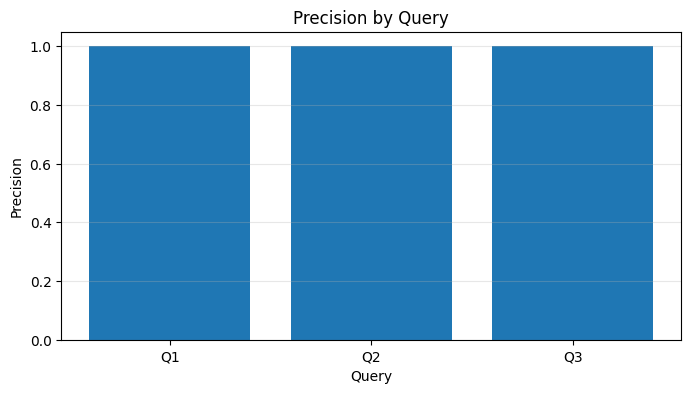

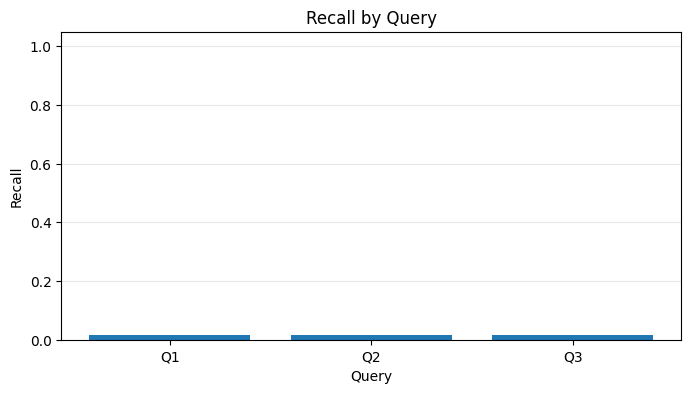

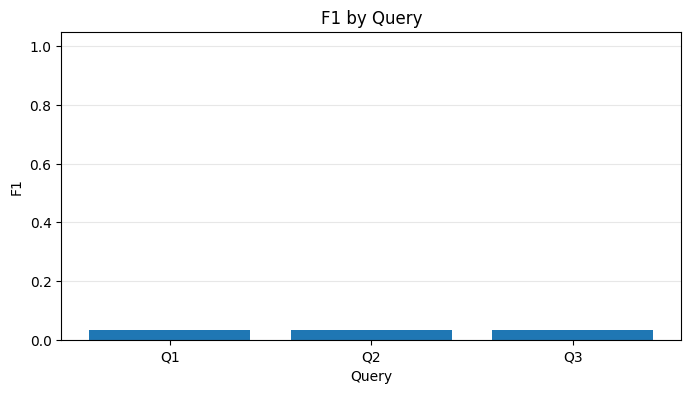

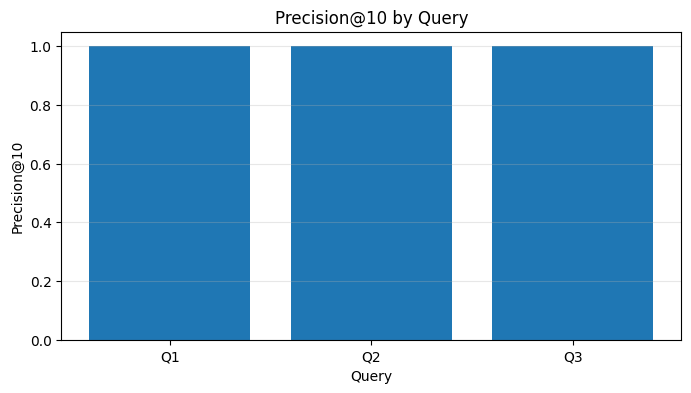

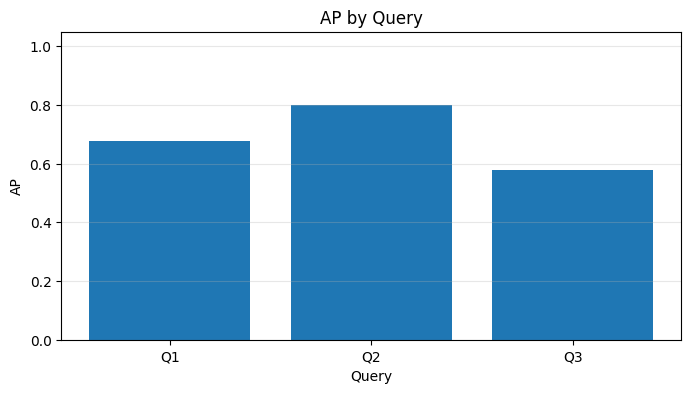

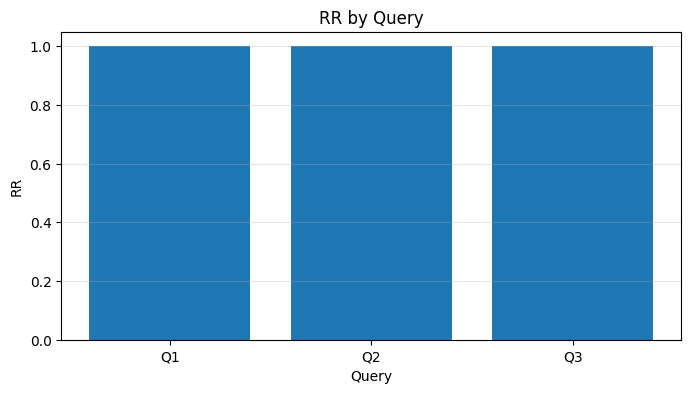

In [44]:
plot_df = evaluation_df[["QueryID", "Precision", "Recall", "F1", "Precision@10", "AP", "RR"]].set_index("QueryID")

for metric in plot_df.columns:
    plt.figure(figsize=(8, 4))
    plt.bar(plot_df.index, plot_df[metric])
    plt.title(f"{metric} by Query")
    plt.xlabel("Query")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

### Talking Points

- These plots make it easier to compare the metric values across different queries.
- We can quickly see which query performed best and where the retrieval system struggled more.
- This visual view supports our written evaluation and reflection.


In [45]:
summary_rows = []

for rep_name in ["Binary", "Raw TF", "TF-IDF"]:
    correct_top1 = 0
    for q in query_set:
        top_category = retrieve_documents(q["QueryText"], representation_name=rep_name, k=1)["Category"].iloc[0]
        if top_category in q["RelevantCategories"]:
            correct_top1 += 1
    summary_rows.append({
        "Representation": rep_name,
        "Correct Top-1 Matches": correct_top1,
        "Out of 5 Queries": 5
    })

representation_summary_df = pd.DataFrame(summary_rows)
representation_summary_df

,Representation,Correct Top-1 Matches,Out of 5 Queries
0,Binary,5,5
1,Raw TF,5,5
2,TF-IDF,5,5


## Reflection and Answers

### 1) Which representation worked best and why?
For our notebook, **TF-IDF worked best overall**. It focused more on important topic words and reduced the influence of common words.

### 2) Did TF-IDF improve over raw term counts?
Yes, in our results TF-IDF was more balanced than raw counts. Raw TF can overvalue repeated words, but TF-IDF gives more importance to words that actually help separate one topic from another.

### 3) What kinds of false positives did we observe?
We mostly saw false positives when documents shared a few overlapping terms with the query but were not actually about the same topic. This happened more easily with Binary and Raw TF than with TF-IDF.

### 4) Why is cosine similarity useful here?
Cosine similarity is useful because it compares the direction of the document and query vectors, not just their length. That helps us focus on term patterns and topic similarity.

### 5) What did we learn from this task?
We learned that vector representation strongly affects retrieval quality. We also saw that preprocessing, weighting, and evaluation all matter when building a useful retrieval system.


### Final Speaking Summary

- In this assignment, we built a complete vector space retrieval system on a real corpus.
- We cleaned the text, created binary, TF, and TF-IDF representations, and used cosine similarity to rank documents.
- After that, we evaluated the system using confusion matrix, precision, recall, F1, Precision@10, AP, MRR, and Kappa.
- From our results, TF-IDF was the best overall because it gave more importance to meaningful topic words.
- This assignment helped us understand that good retrieval is not only about finding matching words, but also about using the right representation and evaluation methods.
